<a href="https://colab.research.google.com/github/BartolomeoML/Lesson_4/blob/main/Lesson_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import pandas as pd

def load_data(url: str) -> pd.DataFrame:
    """
    Загружает датасет по ссылке, выводит базовую структурную информацию
    и возвращает DataFrame.
    """
    print("Начало загрузки данных...")
    # Загружаем данные по прямой ссылке
    df = pd.read_csv(url)
    print("Данные успешно загружены!\n")

    # Выводим общую информацию
    rows, cols = df.shape
    print(f"--- Общая информация ---")
    print(f"Количество строк (объявлений): {rows:,}")
    print(f"Количество колонок (признаков): {cols}")
    print("-" * 30)

    # Выводим техническую информацию о типах данных и памяти
    print("\n--- Сводная информация о колонках и типах данных ---")
    df.info()
    print("-" * 30)

    # Показываем первые 5 строк для визуального ознакомления
    print("\n--- Первые 5 строк датасета ---")
    # Настройка, чтобы в консоли/коллабе отображались все колонки без сокращений
    pd.set_option('display.max_columns', None)
    print(df.head())
    print("-" * 30)

    return df

In [69]:
# Ссылка на файл датасета с GitHub
DATA_URL = "https://raw.githubusercontent.com/BartolomeoML/Lesson_4/refs/heads/main/dataset_used_vehicles.csv"

# Вызов функции загрузки файла датасета
try:
    cars_df = load_data(DATA_URL)
except Exception as e:
    print(f"Ошибка при загрузке данных. Проверьте ссылку и подключение к интернету: {e}")
    cars_df = None

Начало загрузки данных...
Данные успешно загружены!

--- Общая информация ---
Количество строк (объявлений): 426,853
Количество колонок (признаков): 13
------------------------------

--- Сводная информация о колонках и типах данных ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426853 entries, 0 to 426852
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426853 non-null  object 
 1   price         426853 non-null  int64  
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   transmission  424324 non-null  object 
 10  type          334022 non-null  object 
 11  paint_color   296677 non-null  object 
 12  state         426853 non-null  

In [70]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Основная функция предобработки данных.
    Очищает данные, оставляет только топ-20 самых популярных моделей,
    приводит типы к int и возвращает готовый к анализу DataFrame.
    """
    print("Начало предобработки данных...")
    df_clean = df.copy()  # Работаем с копией, чтобы не испортить исходный датасет

    # Удаляем строки, где не заполнены поля с критически важными данными
    df_clean = df_clean.dropna(subset=['price', 'year', 'manufacturer', 'model'])

    # Базовая чистка названий моделей (нижний регистр + удаление пробелов по краям + удаление дефисов)
    df_clean['model'] = df_clean['model'].str.lower().str.strip().str.replace('-', '')

    # Находим ТОП-20 самых популярных моделей
    top_20_models = df_clean['model'].value_counts().head(20).index
    print(f"\nВыбраны топ-20 моделей для дальнейшего анализа:")
    for i, model_name in enumerate(top_20_models, 1):
        print(f"{i}. {model_name}")

    # Фильтруем датасет, оставляем только строки с моделями из топ-20
    df_clean = df_clean[df_clean['model'].isin(top_20_models)]
    print(f"\nРазмер датасета после фильтрации по топ-20 моделям: {df_clean.shape[0]} строк.")

    # Удаляем бесполезные для обучения колонки
    cols_to_drop = ['cylinders', 'condition']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
    df_clean = df_clean.drop(columns=existing_cols_to_drop)

    # Приведение типов данных к целочисленному (int)
    if 'price' in df_clean.columns:
        df_clean['price'] = df_clean['price'].astype(int)
    if 'year' in df_clean.columns:
        df_clean['year'] = df_clean['year'].astype(int)

    # Если пробег имеет пропуски, сначала заполняем их медианой и приводим к int
    if 'odometer' in df_clean.columns:
        df_clean['odometer'] = df_clean['odometer'].fillna(df_clean['odometer'].median())
        df_clean['odometer'] = df_clean['odometer'].astype(int)

    # Фильтруем аномалии (выбросы по цене и пробегу)
    if 'price' in df_clean.columns:
        df_clean = df_clean[(df_clean['price'] >= 500) & (df_clean['price'] <= 90000)]
    if 'odometer' in df_clean.columns:
        df_clean = df_clean[(df_clean['odometer'] >= 100) & (df_clean['odometer'] <= 400000)]

    # Категориальные признаки (тип топлива и тип трансмиссии) заполняем модой (самым частым)
    for col in ['fuel', 'transmission']:
        if col in df_clean.columns:
            most_frequent = df_clean[col].mode()[0]
            df_clean[col] = df_clean[col].fillna(most_frequent)

    print(f"\nПредобработка завершена. Оставшиеся пропуски: {df_clean.isnull().sum().sum()}")
    print(f"Итоговая размерность датасета: {df_clean.shape}")

    return df_clean

In [71]:
cleaned_dataset = preprocess_data(cars_df)
print(cleaned_dataset)

Начало предобработки данных...

Выбраны топ-20 моделей для дальнейшего анализа:
1. f150
2. silverado 1500
3. 1500
4. camry
5. silverado
6. accord
7. wrangler
8. civic
9. altima
10. escape
11. 2500
12. tacoma
13. explorer
14. grand cherokee
15. f250
16. corolla
17. mustang
18. crv
19. fusion
20. equinox

Размер датасета после фильтрации по топ-20 моделям: 61897 строк.

Предобработка завершена. Оставшиеся пропуски: 29874
Итоговая размерность датасета: (53904, 11)
            region  price  year manufacturer           model fuel  odometer  \
1           auburn  22590  2010    chevrolet  silverado 1500  gas     71229   
7           auburn  35000  2019       toyota          tacoma  gas     43000   
143     birmingham  13950  2011       toyota          tacoma  gas    151060   
160     birmingham   4500  2008         ford         mustang  gas    187016   
166     birmingham   5900  1998         ford            f150  gas    214000   
...            ...    ...   ...          ...             ...

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

class DataVisualizer:
    def __init__(self, df: pd.DataFrame):
        self.df = df
        # Хранилище для запланированных графиков (очередь задач)
        self.plot_queue = []

    def add_histogram(self, column: str, bins: int = 30):
        """Добавляет гистограмму в очередь на построение"""
        self.plot_queue.append({
            'type': 'hist',
            'column': column,
            'bins': bins,
            'title': f'Гистограмма распределения для {column}'
        })
        print(f"Добавлен график: гистограмма для '{column}'")

    def add_scatter(self, x_col: str, y_col: str):
        """Добавляет диаграмму рассеяния в очередь"""
        self.plot_queue.append({
            'type': 'scatter',
            'x': x_col,
            'y': y_col,
            'title': f"Диаграмма рассеяния: {y_col} в зависимости от {x_col}"
        })
        print(f"Добавлен график: scatter plot для '{x_col}' и '{y_col}'")

    def add_line(self, x_col: str, y_col: str):
        """Добавляет линейный график в очередь"""
        self.plot_queue.append({
            'type': 'line',
            'x': x_col,
            'y': y_col,
            'title': f"Линейный график: среднее значение {y_col} по {x_col}"
        })
        print(f"Добавлен график: линейный для '{x_col}' и '{y_col}'")

    def add_boxplot(self, x_col: str = 'price', y_col: str = 'model'):
        """Добавляет ящик с усами (Box Plot) в очередь"""
        self.plot_queue.append({
            'type': 'boxplot',
            'x': x_col,
            'y': y_col,
            'title': f"Распределение '{x_col}' по категориям '{y_col}'"
        })
        print(f"Добавлен график: boxplot для '{x_col}' по '{y_col}'")

    def add_correlation(self, columns: list = None):
        """Добавляет тепловую карту корреляции числовых признаков в очередь"""
        if columns is None:
            columns = ['price', 'year', 'odometer']
        self.plot_queue.append({
            'type': 'correlation',
            'columns': columns,
            'title': "Матрица корреляции числовых признаков"
        })
        print(f"Добавлен график: тепловая карта корреляции для {columns}")

    def add_countplot(self, column: str = 'model'):
        """Добавляет график распределения классов (количество записей по категориям)"""
        self.plot_queue.append({
            'type': 'countplot',
            'column': column,
            'title': f"Распределение количества объявлений по '{column}'"
        })
        print(f"Добавлен график: countplot для '{column}'")

    def add_missingness(self):
        """Добавляет график заполненности данных (оценку пропусков) в очередь"""
        self.plot_queue.append({
            'type': 'missingness',
            'title': "Визуализация заполненности столбцов датасета"
        })
        print("Добавлен график: оценка пропущенных значений (missingness)")

    def show_all_plots(self):
        """Последовательно отрисовывает все запланированные графики из очереди"""
        if not self.plot_queue:
            print("Очередь графиков пуста.")
            return

        for plot in self.plot_queue:
            plt.figure(figsize=(12, 6))

            if plot['type'] == 'hist':
                sns.histplot(self.df[plot['column']], bins=plot['bins'], kde=True)
                plt.xlabel(plot['column'])

            elif plot['type'] == 'scatter':
                # Для ускорения отрисовки больших данных берём случайную подвыборку
                sample_size = min(5000, len(self.df))
                sample_df = self.df.sample(sample_size, random_state=42)
                sns.scatterplot(data=sample_df, x=plot['x'], y=plot['y'], alpha=0.5)
                plt.xlabel(plot['x'])
                plt.ylabel(plot['y'])

            elif plot['type'] == 'line':
                grouped = self.df.groupby(plot['x'])[plot['y']].mean().reset_index()
                sns.lineplot(data=grouped, x=plot['x'], y=plot['y'], marker='o')
                plt.xlabel(plot['x'])
                plt.ylabel(f"Среднее {plot['y']}")

            elif plot['type'] == 'boxplot':
                # Сортируем модели по медианной цене
                order = self.df.groupby(plot['y'])[plot['x']].median().sort_values(ascending=False).index
                sns.boxplot(data=self.df, x=plot['x'], y=plot['y'], order=order, orient='h')
                plt.xlabel(plot['x'])
                plt.ylabel(plot['y'])

            elif plot['type'] == 'correlation':
                # Выбираем только существующие в датасете числовые колонки
                existing_cols = [c for c in plot['columns'] if c in self.df.columns]
                corr_matrix = self.df[existing_cols].corr()
                sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")

            elif plot['type'] == 'countplot':
                # Сортируем столбцы по убыванию частоты
                order = self.df[plot['column']].value_counts().index
                sns.countplot(data=self.df, y=plot['column'], order=order, orient='h')
                plt.xlabel("Количество объявлений")
                plt.ylabel(plot['column'])

            elif plot['type'] == 'missingness':
                # Закрываем пустое окно matplotlib, так как missingno строит график сам
                plt.close()
                msno.bar(self.df, figsize=(12, 6))

            plt.title(plot['title'])
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.show()

Добавлен график: гистограмма для 'price'
Добавлен график: scatter plot для 'odometer' и 'price'
Добавлен график: линейный для 'year' и 'price'
Добавлен график: boxplot для 'price' по 'model'
Добавлен график: тепловая карта корреляции для ['price', 'year', 'odometer']
Добавлен график: countplot для 'model'
Добавлен график: оценка пропущенных значений (missingness)


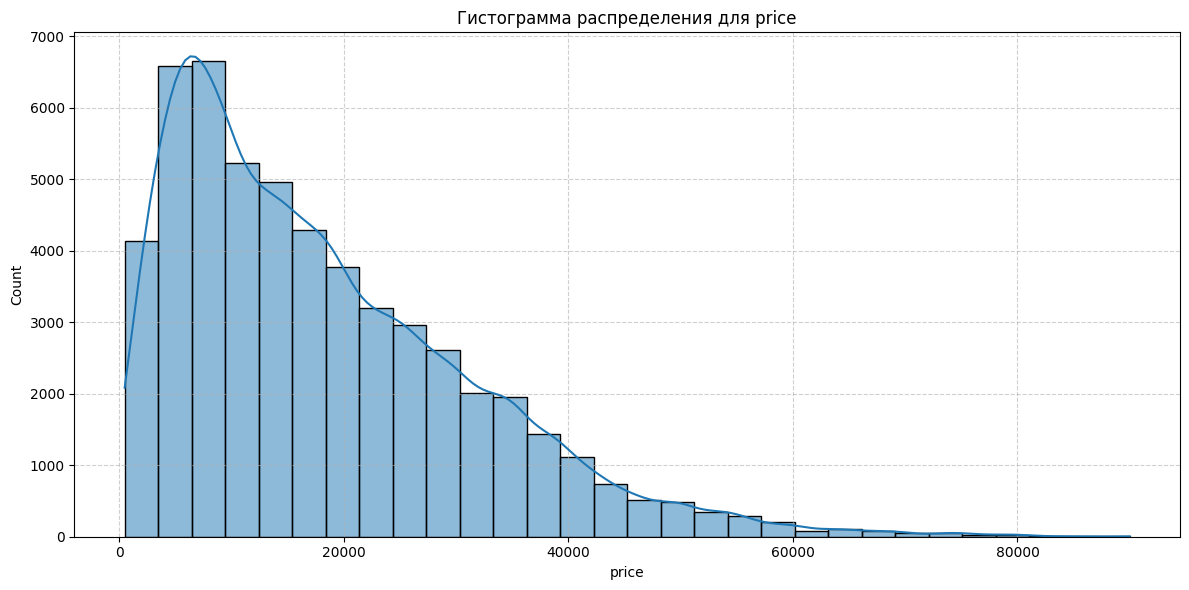

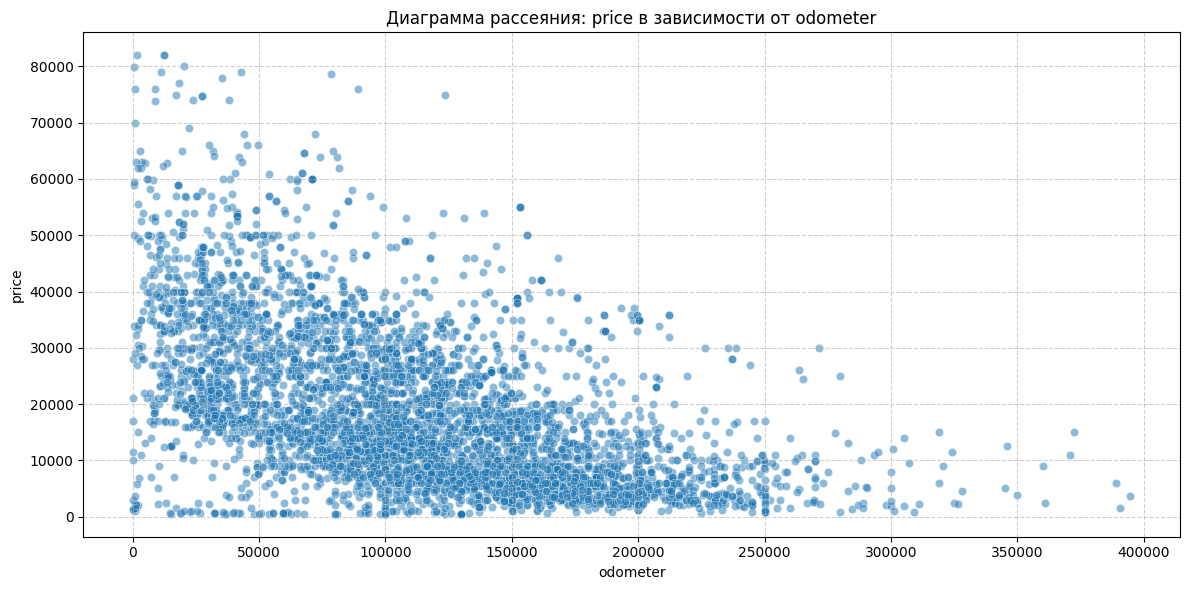

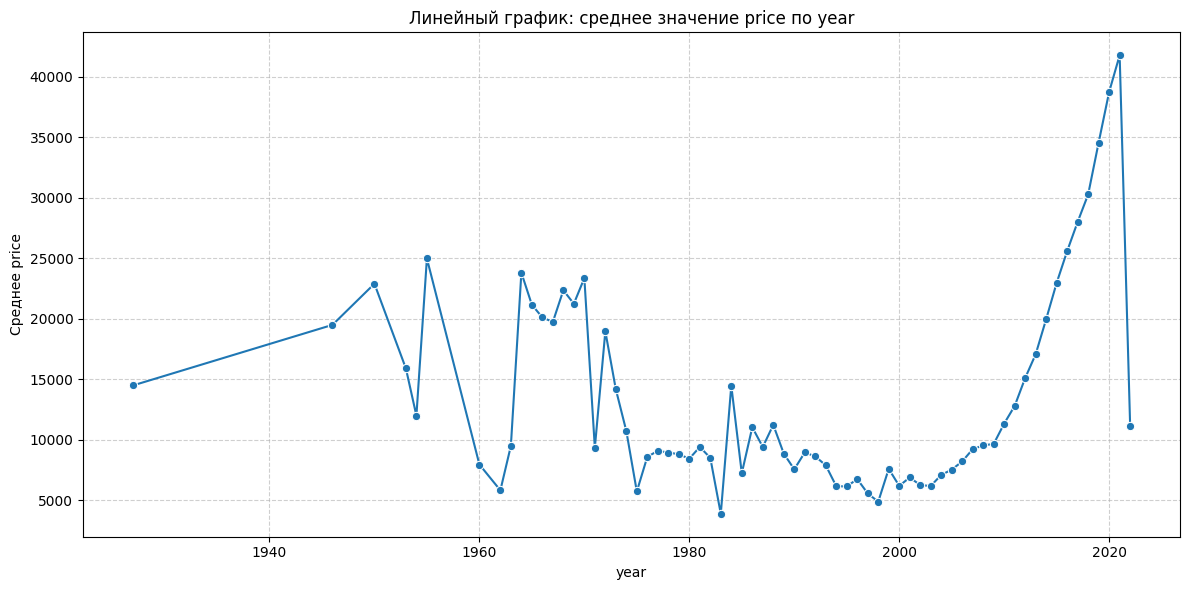

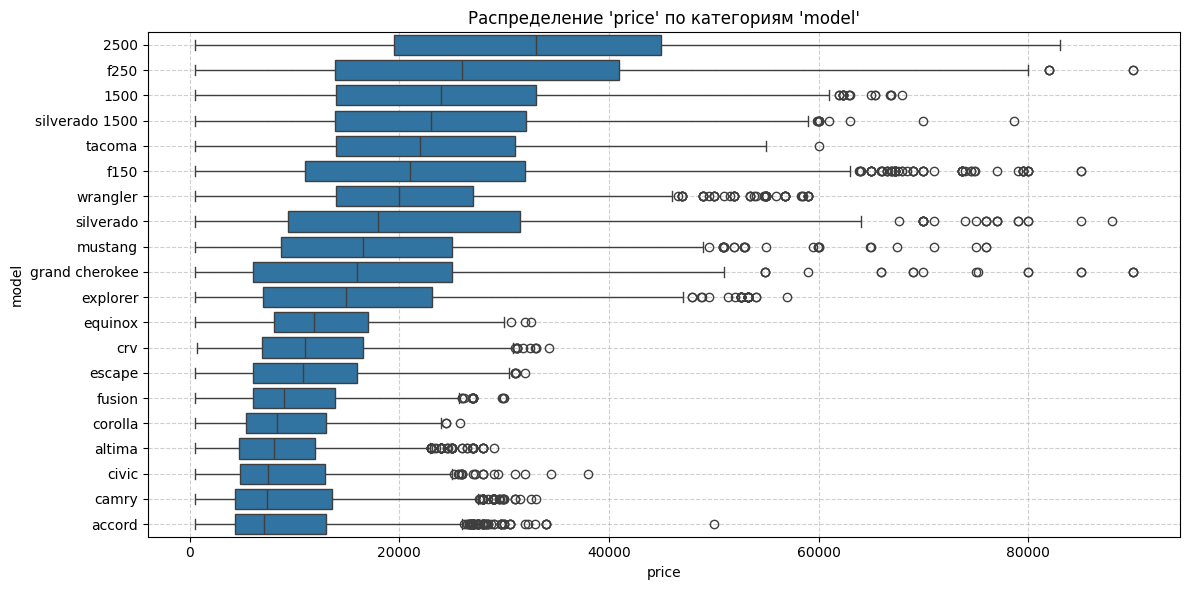

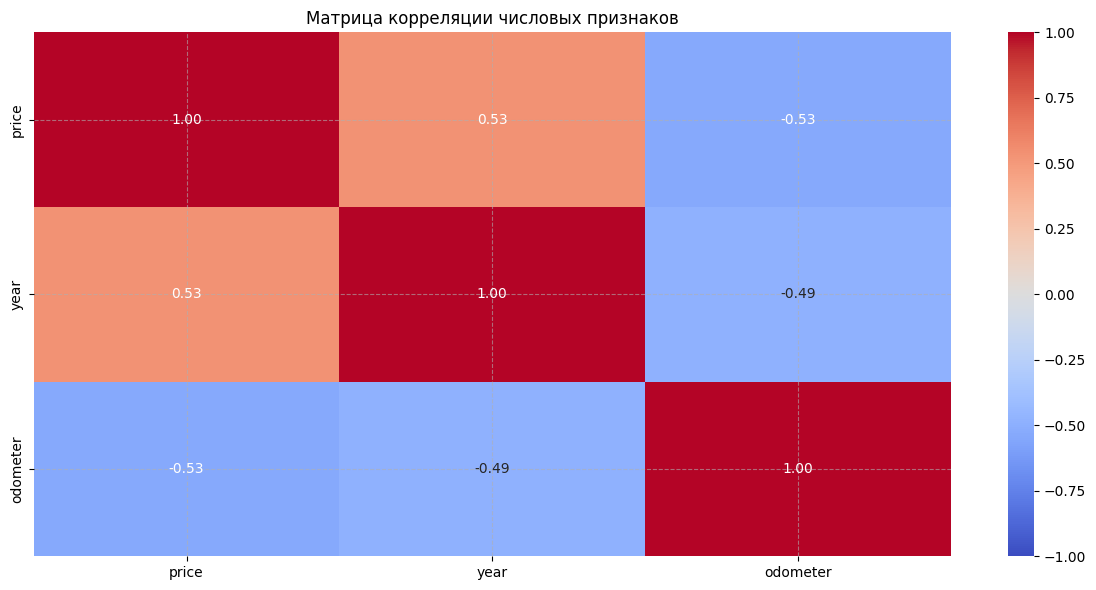

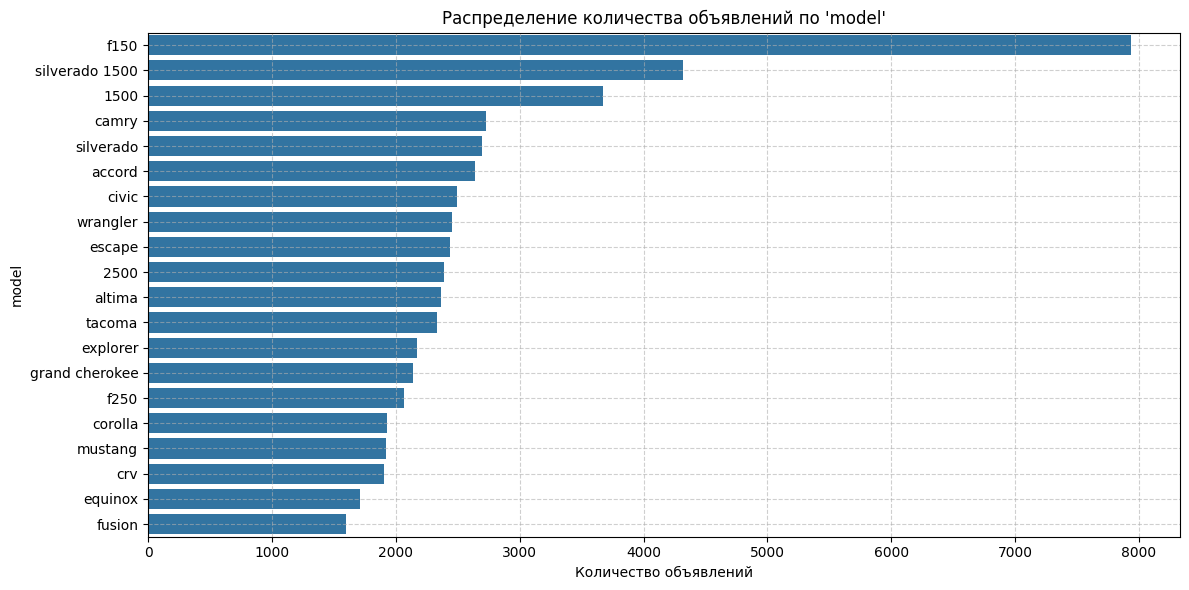

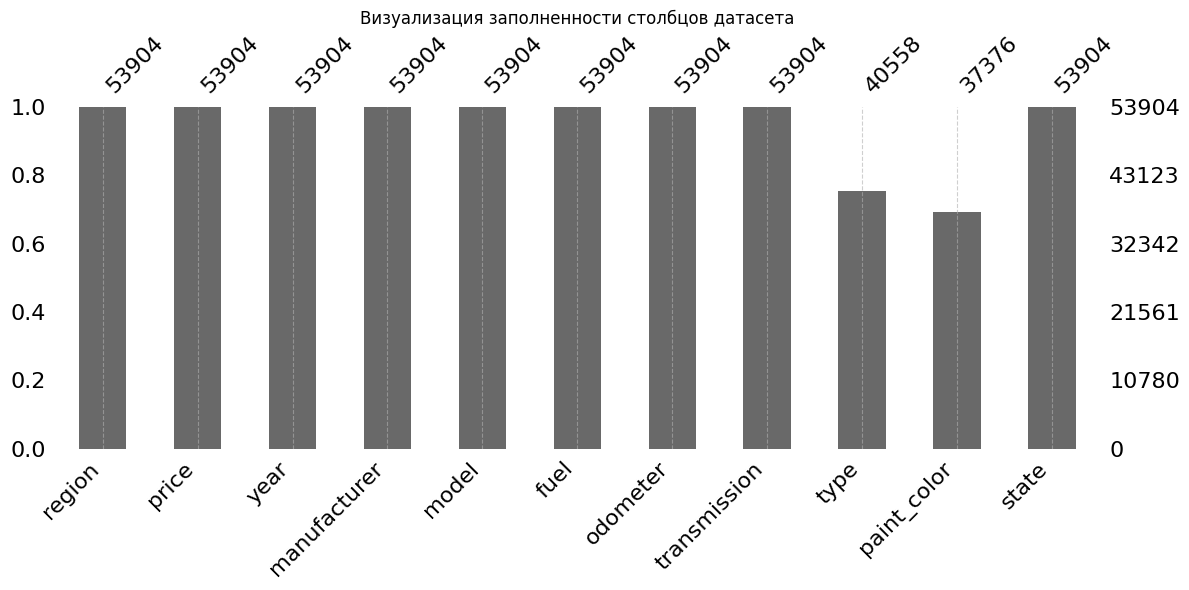

In [67]:
# Создаём объект визуализатора на базе очищенных данных
visualizer = DataVisualizer(cleaned_dataset)

# Набираем очередь базовых графиков
visualizer.add_histogram(column='price')
visualizer.add_scatter(x_col='odometer', y_col='price')
visualizer.add_line(x_col='year', y_col='price')
visualizer.add_boxplot(x_col='price', y_col='model')
visualizer.add_correlation(columns=['price', 'year', 'odometer'])
visualizer.add_countplot(column='model')
visualizer.add_missingness()

# Отрисовываем все графики по очереди
visualizer.show_all_plots()